In [83]:
import os
import cv2
import torch
import joblib
import numpy as np
import pandas as pd

from PIL import Image
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision import models

from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt


In [84]:
class_names = [
    "Healthy",
    "Early Deficiency",
    "Critical Deficiency"
]


In [85]:
features = [
    "N", "P", "K",
    "ph",
    "soil_moisture",
    "temperature",
    "humidity",
    "rainfall",
    "sunlight_exposure"
]

In [86]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [87]:
# 🔥 For recommendation (train data)
train_df = pd.read_csv("train_data.csv")

# 🔥 For evaluation (IMPORTANT)
test_df = pd.read_csv("test_data.csv")

In [88]:
class ImageModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = models.efficientnet_b3(weights=None)

        self.model.classifier = nn.Sequential(
            nn.Linear(1536, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, 3)
        )

    def forward(self, x):
        return self.model(x)

In [89]:
image_model = ImageModel()
image_model.load_state_dict(torch.load("image_model.pth", map_location=device))
image_model.to(device)
image_model.eval()

ImageModel(
  (model): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
              (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
              (scale_ac

In [90]:
scaler = joblib.load("rf_scaler.pkl")
rf_model = joblib.load("rf_metadata_model.pkl")

rf_classes = rf_model.classes_ 

In [91]:
transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [100]:
def image_prediction(image_path):
    img = cv2.imread(image_path)

    # ✅ Handle invalid image
    if img is None:
        print(f"⚠️ Skipping invalid image: {image_path}")
        return None

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    pil_img = Image.fromarray(img)
    img_tensor = transform(pil_img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = image_model(img_tensor)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()[0]

    return probs

In [101]:
def metadata_prediction(metadata_dict):
    df = pd.DataFrame([metadata_dict])
    scaled = scaler.transform(df[features])

    probs = rf_model.predict_proba(scaled)[0]

    ordered_probs = np.zeros(len(class_names))

    for i, cls in enumerate(rf_classes):
        idx = class_names.index(cls)
        ordered_probs[idx] = probs[i]

    return ordered_probs

In [102]:
def dynamic_fusion(image_prob, metadata_prob):

    image_weight = 0.7
    metadata_weight = 0.3

    final_prob = (
        image_weight * image_prob +
        metadata_weight * metadata_prob
    )

    return final_prob

In [103]:
def get_best_recommendation(metadata_dict, predicted_class):

    class_data = train_df[train_df["Label"] == predicted_class]

    X = class_data[features]
    y = class_data["Recommendation"].values

    X_scaled = scaler.transform(X)

    input_df = pd.DataFrame([metadata_dict])[features]
    input_scaled = scaler.transform(input_df)

    distances = np.linalg.norm(X_scaled - input_scaled, axis=1)

    top_k = np.argsort(distances)[:5]
    idx = np.random.choice(top_k)

    return y[idx]


In [ ]:
def multimodal_predict(image_path, metadata_dict):

    img_prob = image_prediction(image_path)
    meta_prob = metadata_prediction(metadata_dict)

    final_prob = dynamic_fusion(img_prob, meta_prob)

    final_class = class_names[np.argmax(final_prob)]
    confidence = np.max(final_prob) * 100

    recommendation = get_best_recommendation(metadata_dict, final_class)

    print("\n===== Crop Health Diagnosis =====")
    print("\nImage Probabilities:", np.round(img_prob, 4))
    print("Metadata Probabilities:", np.round(meta_prob, 4))
    print("Fusion Probabilities:", np.round(final_prob, 4))

    print("\nPredicted Class:", final_class)
    print(f"Confidence Score: {confidence:.2f}%")

    print("\nRecommendation:")
    print(recommendation)


In [110]:
def evaluate_multimodal():

    test_folder = "test"

    all_preds = []
    all_labels = []

    index = 0

    for class_name in class_names:
        class_path = os.path.join(test_folder, class_name, "images")

        if not os.path.exists(class_path):
            print(f"⚠️ Folder not found: {class_path}")
            continue

        for img_file in os.listdir(class_path):

            # ✅ Skip non-image files
            if not img_file.lower().endswith((".jpg", ".jpeg", ".png")):
                continue

            img_path = os.path.join(class_path, img_file)

            # ✅ Prevent index overflow
            if index >= len(test_df):
                break

            metadata_dict = test_df.iloc[index][features].to_dict()

            # 🔹 Image prediction
            img_prob = image_prediction(img_path)

            # ✅ Skip invalid images
            if img_prob is None:
                continue

            # 🔹 Metadata prediction
            meta_prob = metadata_prediction(metadata_dict)

            # 🔹 Fusion
            final_prob = dynamic_fusion(img_prob, meta_prob)

            pred_class = np.argmax(final_prob)

            all_preds.append(pred_class)
            all_labels.append(class_names.index(class_name))

            index += 1

    # =========================
    # RESULTS
    # =========================
    acc = accuracy_score(all_labels, all_preds)

    print("\n🔥 Multimodal Accuracy:", acc)

    print("\nClassification Report:\n")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # =========================
    # CONFUSION MATRIX
    # =========================
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title("Multimodal Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [111]:
image_path = "test/Early Deficiency/images/Early-Deficiency-58-_90_jpg.rf.d4febfd2040ae5217b7c41ef51ee2484.jpg"
metadata ={
"N": 52,
"P": 44,
"K": 43,
"ph": 5.0,
"soil_moisture": 14.3,
"temperature": 20.1,
"humidity": 36.2,
"rainfall": 45.0,
"sunlight_exposure": 7.2
}
multimodal_predict(image_path, metadata)


===== Crop Health Diagnosis =====

Image Probabilities: [0.     0.9989 0.0011]
Metadata Probabilities: [0.0131 0.5707 0.4161]
Fusion Probabilities: [0.004  0.8704 0.1256]

Predicted Class: Early Deficiency
Confidence Score: 87.04%

Recommendation:
Attention: Early signs of deficiency detected. Nitrogen is relatively low. Apply nitrogen-rich fertilizers like urea or compost. Phosphorus is below optimal. Use DAP or bone meal to improve root development. Potassium is insufficient. Add potash fertilizers to improve plant strength. Soil moisture is low. Ensure regular irrigation and consider mulching. Soil pH is below optimal range. Apply lime to balance soil acidity.



🔥 Multimodal Accuracy: 0.9741379310344828

Classification Report:

                     precision    recall  f1-score   support

            Healthy       1.00      1.00      1.00        43
   Early Deficiency       0.93      1.00      0.96        38
Critical Deficiency       1.00      0.91      0.96        35

           accuracy                           0.97       116
          macro avg       0.98      0.97      0.97       116
       weighted avg       0.98      0.97      0.97       116



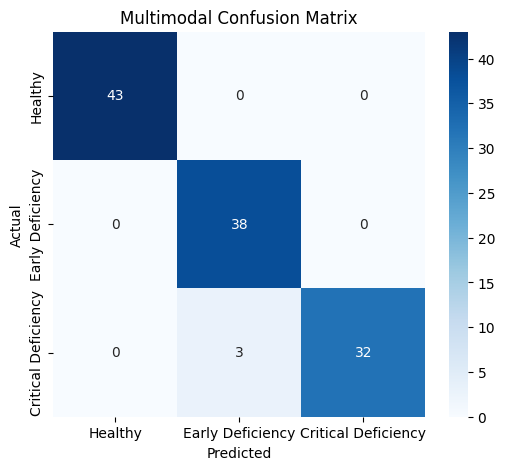

In [112]:
evaluate_multimodal()